<a href="https://colab.research.google.com/github/uditnarayanpandey/Machine_Learning_Practice/blob/Master/Deep%20Learning/src/mnist_multiclass_classification/mnist_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Multiclass Clasification Using **ANN**

---
This is just a sample code to learn the implementation of **Deep Learning Algorithms** using **Tesorflow** and **Keras**

### 1. **Importing Necessary Libraries**

---
Importing all the necessary libraries that would be required to manipulation of the dataset along with visualizing the graphs

In [ ]:
#importing necessary libraries

#libraries for data manipulation
import pandas as pd
import numpy as np

#library for visualisation
import matplotlib.pyplot as plt

#libraries from sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

#libraries for tensorflow
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Flatten


### 2. **Reading The Dataset**

---
Read the dataset

In [ ]:
#reading the dataset and splitting it into train and test
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [ ]:
# checking the shape of the dataset
X_train.shape

(60000, 28, 28)

From the above shape we got to know that there are 60000 images with dimensions (28 X 28)

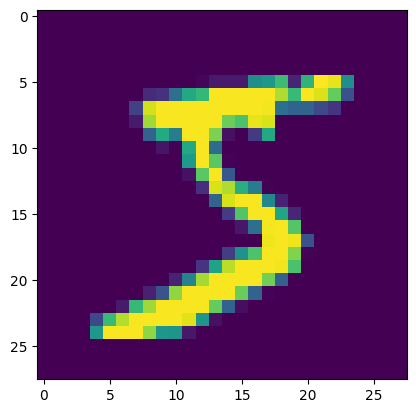

In [ ]:
#printing 1st image (28 X 28 dimensional image)
plt.imshow(X_train[0])

In [ ]:
#checking the test set shape
X_test.shape

(10000, 28, 28)

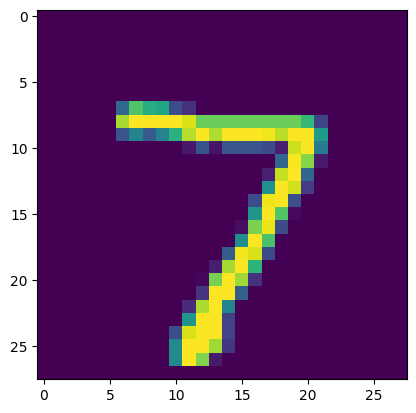

In [ ]:
#displaying example from X_test
plt.imshow(X_test[0])

### 3. **Data Cleaning**

---
Cleaning the dataset for further Analysis or Implementation



> As we can see, the values in the dataset ranges from **0 to 255**. We have to scale the data down and bring it in the range from **0 to 1** as the convergence of the function happens quicker if all our values are of same scale.

> We will devide all the values with the maximun value present in the dataset **(255 in this case)**



In [ ]:
# prompt: write a function to divide all the values in X_train and X_test by 255 in which the function only takes the name of the dataframe on which the operation needs to be run

def normalize(x):
  x = x/255
  return x

X_train = normalize(X_train)
X_test = normalize(X_test)


Since the shape of our one image is in the 2D which we need to convert to 1D to pass it to the neural network. So **(28 X 28) -> 784 (1D image)** so that we can pass it to the 1st layer of the neural network

### 4. **APPLYING ALGORITHM**

---
Applying ML Algorithm on the dataset for classification using Keras and Tensorflow

In [ ]:
#building a sequential model
model = Sequential()

model.add(Input(shape=(28,28)))
# model.add(Flatten(input_shape=(28,28)))
model.add(Flatten()) #input is already defined as a shape in Input layer
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(100, activation='softmax'))

In [ ]:
#summary of the model
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 100)                 │           6,500 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 115,236 (450.14 KB)

 Trainable params: 115,236 (450.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#compiling a model
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'Adam', metrics = ['accuracy'])

In [ ]:
#training the model
history = model.fit(X_train, y_train, epochs=15, validation_split=0.2)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8186 - loss: 0.7043 - val_accuracy: 0.9482 - val_loss: 0.1794
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9572 - loss: 0.1415 - val_accuracy: 0.9643 - val_loss: 0.1190
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9718 - loss: 0.0910 - val_accuracy: 0.9681 - val_loss: 0.1070
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9800 - loss: 0.0662 - val_accuracy: 0.9682 - val_loss: 0.1055
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9841 - loss: 0.0518 - val_accuracy: 0.9741 - val_loss: 0.0922
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9874 - loss: 0.0398 - val_accuracy: 0.9705 - val_loss: 0.1098
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9897 - loss: 0.0339 - val_accuracy: 0.9720 - val_loss: 0.1106
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9920 - loss: 0.025

In [ ]:
#checking the weights & biases of the 0th layer of the architecture
model.layers[1].get_weights()

[array([[-0.00870535,  0.06346817,  0.01693642, ...,  0.0122086 ,
         -0.00600351, -0.02910151],
        [-0.00344723, -0.06671259, -0.07125352, ...,  0.07186141,
         -0.02458325,  0.07864206],
        [ 0.03180119, -0.06634996, -0.04723451, ...,  0.03232596,
          0.03383963,  0.0063934 ],
        ...,
        [-0.02112531,  0.07986756,  0.05845097, ..., -0.01204279,
         -0.02933949, -0.05264252],
        [ 0.02182263,  0.07609644,  0.03023702, ..., -0.04331363,
          0.03708035, -0.07809523],
        [-0.06767438,  0.06369481,  0.00047801, ...,  0.07993222,
          0.01808666, -0.02939837]], dtype=float32),
 array([-0.06393147, -0.04271078,  0.01738961,  0.10401675, -0.10878819,
         0.01036257, -0.03901152, -0.03056644,  0.06169543,  0.09148981,
         0.07806557, -0.08347033,  0.15847602,  0.00069391,  0.0271866 ,
         0.13674289, -0.01065032, -0.10708602, -0.09939047,  0.05475344,
        -0.12178362, -0.05153172,  0.08756681, -0.0198412 ,  0.146

In [ ]:
#prediction on the test set
y_prob =  model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
y_prob

array([[6.0106331e-10, 2.6426853e-12, 8.3456332e-11, ..., 8.2971582e-23,
        1.1186325e-21, 8.0862932e-25],
       [4.2283624e-14, 2.1192970e-09, 9.9999994e-01, ..., 2.1829591e-23,
        3.1090334e-22, 2.6393245e-24],
       [1.9692317e-09, 9.9999756e-01, 2.1127669e-08, ..., 1.6395766e-14,
        1.1866650e-13, 2.8791937e-14],
       ...,
       [3.0533382e-19, 1.3032729e-12, 4.4837635e-20, ..., 1.1915015e-27,
        1.4815480e-26, 3.9605350e-26],
       [4.6836492e-17, 4.0302815e-16, 7.4668728e-20, ..., 7.1676048e-27,
        1.6665214e-22, 3.1578696e-24],
       [1.1302511e-12, 1.2638583e-22, 3.9572474e-16, ..., 3.6112428e-26,
        1.1967047e-25, 1.1136221e-27]], dtype=float32)

This gives the probability of the image being the number at that index. We need to find out teh index from each array where the value is maximum

In [ ]:
y_pred = y_prob.argmax(axis=1)

In [ ]:
accuracy_score(y_test, y_pred)

0.9795

In [ ]:
history.history

{'accuracy': [0.9044166803359985,
  0.9598541855812073,
  0.9723333120346069,
  0.9787708520889282,
  0.9826874732971191,
  0.9865833520889282,
  0.9896458387374878,
  0.9903125166893005,
  0.9913541674613953,
  0.9933124780654907,
  0.9937083125114441,
  0.9948541522026062,
  0.9946041703224182,
  0.9954166412353516,
  0.9958958625793457],
 'loss': [0.34164348244667053,
  0.13306455314159393,
  0.09088017046451569,
  0.06845289468765259,
  0.053896211087703705,
  0.041722167283296585,
  0.03431931510567665,
  0.029451696202158928,
  0.024795273318886757,
  0.019773131236433983,
  0.018336355686187744,
  0.015319290570914745,
  0.016026515513658524,
  0.013264454901218414,
  0.011860792525112629],
 'val_accuracy': [0.9481666684150696,
  0.9642500281333923,
  0.9680833220481873,
  0.9681666493415833,
  0.9740833044052124,
  0.9704999923706055,
  0.972000002861023,
  0.9752500057220459,
  0.9727500081062317,
  0.9752500057220459,
  0.9742500185966492,
  0.9697499871253967,
  0.9742500185

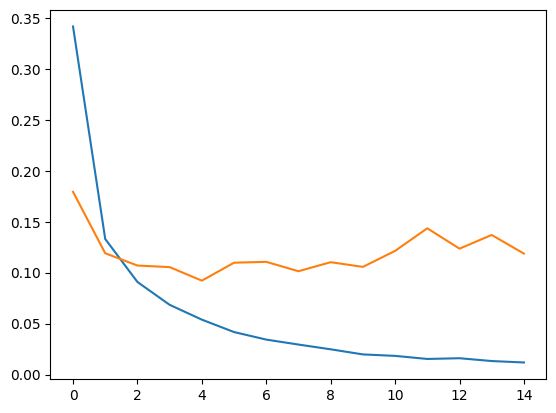

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

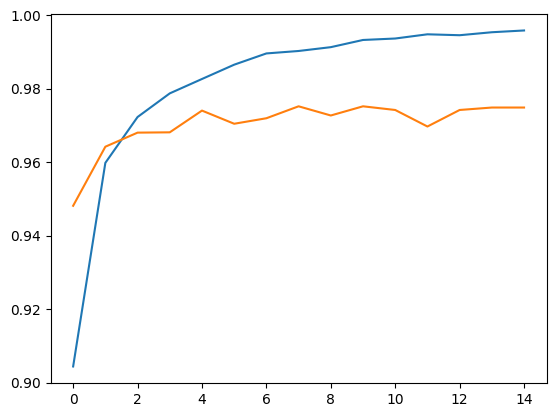

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

It's a case of overfitting. there are ways to reduce overfitting that is covered in the later part of the learning


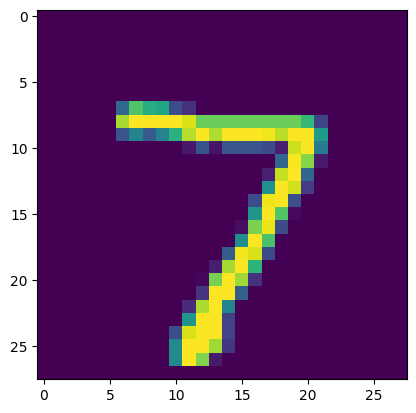

In [ ]:
#testing on the test dataset

plt.imshow(X_test[0])

In [ ]:
model.predict(X_test[0].reshape(1, 28, 28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


array([7])

In [ ]:
X_test[0].reshape(1, 28, 28)

array([[[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.